## Imbalanced

Imbalance data refers to a situation in which the classes within the dataset are not represented equally.

**Is a classification problem that affects the target variable.**


#### Loading and preparing the data

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import precision_score, recall_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler

from sklearn.utils import resample

In [2]:
titanic = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/titanic_train.csv")
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


- Check for anomalies

In [3]:
titanic.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Upon checking the number of null values, we are going to drop the column **Cabin** and also dropping rows where **Age** is null.

In [4]:
titanic.drop(columns="Cabin", inplace = True)
titanic.dropna(inplace=True)

In [5]:
titanic.shape

(712, 11)

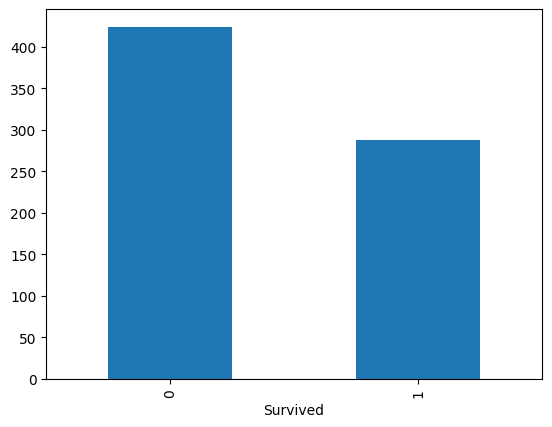

In [6]:
survived = titanic["Survived"].value_counts()
survived.plot(kind="bar")
plt.show()

- Preparing the data before modeling

In [7]:
titanic.drop(columns=["Name", "Ticket", "PassengerId"], inplace = True)

In [8]:
titanic["Sex"] = titanic["Sex"].replace({"male":0,
                                         "female":1})

/tmp/ipython-input-1812906043.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  titanic["Sex"] = titanic["Sex"].replace({"male":0,


In [9]:
titanic = pd.get_dummies(titanic, columns=["Embarked"])

In [ ]:
titanic.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,False,True
1,1,1,1,38.0,1,0,71.2833,True,False,False
2,1,3,1,26.0,0,0,7.9250,False,False,True
3,1,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,0,35.0,0,0,8.0500,False,False,True


For baseline, we will train a Logistic Regression in imbalanced data.

In [10]:
features = titanic.drop(columns = ["Survived"])
target = titanic["Survived"]

X_train, X_test, y_train, y_test = train_test_split(features, target,random_state=0)

In [11]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled_np = scaler.transform(X_train)
X_test_scaled_np = scaler.transform(X_test)

In [12]:
log_reg = LogisticRegression()

In [13]:
X_train_scaled_df = pd.DataFrame(X_train_scaled_np, columns=X_train.columns, index=X_train.index)
X_test_scaled_df  = pd.DataFrame(X_test_scaled_np, columns=X_test.columns, index=X_test.index)

In [14]:
log_reg.fit(X_train_scaled_df, y_train)

LogisticRegression()

In [15]:
log_reg.score(X_test_scaled_df, y_test)

0.7752808988764045

In [16]:
y_pred_test_log = log_reg.predict(X_test_scaled_df)
print(classification_report(y_pred = y_pred_test_log, y_true = y_test))

              precision    recall  f1-score   support

           0       0.79      0.84      0.81       104
           1       0.75      0.69      0.72        74

    accuracy                           0.78       178
   macro avg       0.77      0.76      0.77       178
weighted avg       0.77      0.78      0.77       178



#### Oversampling

In [17]:
train = pd.DataFrame(X_train_scaled_np, columns=X_train.columns, index=X_train.index)

In [18]:
train["Survived"] = y_train.values

In [19]:
survived = train[train["Survived"] == 1]
no_survived = train[train["Survived"] == 0]

In [20]:
len(survived),len(no_survived)

(214, 320)

In [21]:
yes_oversampled = resample(survived,
                                    replace=True,
                                    n_samples = len(no_survived),
                                    random_state=0)

In [22]:
train_over = pd.concat([yes_oversampled, no_survived])
train_over

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Survived
58,-0.307443,1.345558,-1.709635,0.505881,1.728237,-0.135456,-0.494727,-0.202326,0.555719,1
651,-0.307443,1.345558,-0.793837,-0.545249,0.616335,-0.221988,-0.494727,-0.202326,0.555719,1
576,-0.307443,1.345558,0.333299,-0.545249,-0.495567,-0.404161,-0.494727,-0.202326,0.555719,1
543,-0.307443,-0.743186,0.192407,0.505881,-0.495567,-0.167336,-0.494727,-0.202326,0.555719,1
523,-1.505798,1.345558,1.037759,-0.545249,0.616335,0.415239,2.021315,-0.202326,-1.799471,1
...,...,...,...,...,...,...,...,...,...,...
753,0.890912,-0.743186,-0.441607,-0.545249,-0.495567,-0.497146,-0.494727,-0.202326,0.555719,0
885,0.890912,1.345558,0.685529,-0.545249,5.063942,-0.110407,-0.494727,4.942527,-1.799471,0
239,-0.307443,-0.743186,0.262853,-0.545249,-0.495567,-0.417369,-0.494727,-0.202326,0.555719,0
791,-0.307443,-0.743186,-0.934729,-0.545249,-0.495567,-0.167336,-0.494727,-0.202326,0.555719,0


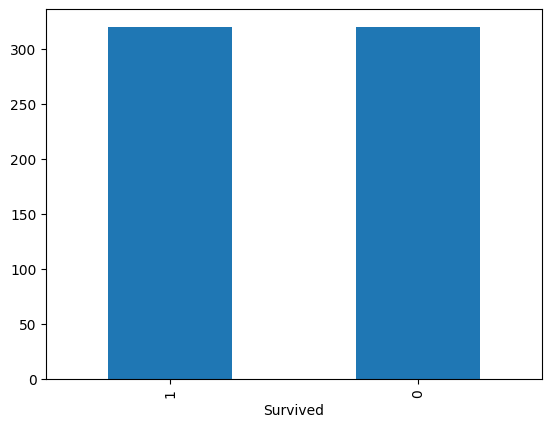

In [23]:
survived_plt = train_over["Survived"].value_counts()
survived_plt.plot(kind="bar")
plt.show()

- Now, with balanced data, we will create a new instance of Logistic Regression.

In [24]:
X_train_over = train_over.drop(columns = ["Survived"])
y_train_over = train_over["Survived"]

In [25]:
log_reg = LogisticRegression()
log_reg.fit(X_train_over, y_train_over)

LogisticRegression()

In [26]:
y_pred_test_log = log_reg.predict(X_test_scaled_df)
print(classification_report(y_pred = y_pred_test_log, y_true = y_test))

              precision    recall  f1-score   support

           0       0.82      0.81      0.82       104
           1       0.74      0.76      0.75        74

    accuracy                           0.79       178
   macro avg       0.78      0.78      0.78       178
weighted avg       0.79      0.79      0.79       178



#### Undersampling

Undersampling involves removing data points from the majority class to align its size with that of the minority class

In [27]:
train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Survived
138,0.890912,-0.743186,-0.934729,-0.545249,-0.495567,-0.473083,-0.494727,-0.202326,0.555719,0
619,-0.307443,-0.743186,-0.230269,-0.545249,-0.495567,-0.449705,-0.494727,-0.202326,0.555719,0
130,0.890912,-0.743186,0.262853,-0.545249,-0.495567,-0.497146,2.021315,-0.202326,-1.799471,0
621,-1.505798,-0.743186,0.896867,0.505881,-0.495567,0.316410,-0.494727,-0.202326,0.555719,1
676,0.890912,-0.743186,-0.335938,-0.545249,-0.495567,-0.494337,-0.494727,-0.202326,0.555719,0
...,...,...,...,...,...,...,...,...,...,...
885,0.890912,1.345558,0.685529,-0.545249,5.063942,-0.110407,-0.494727,4.942527,-1.799471,0
239,-0.307443,-0.743186,0.262853,-0.545249,-0.495567,-0.417369,-0.494727,-0.202326,0.555719,0
791,-0.307443,-0.743186,-0.934729,-0.545249,-0.495567,-0.167336,-0.494727,-0.202326,0.555719,0
705,-0.307443,-0.743186,0.685529,-0.545249,-0.495567,-0.167336,-0.494727,-0.202326,0.555719,0


In [28]:
no_undersampled = resample(no_survived,
                                    replace=False,
                                    n_samples = len(survived),
                                    random_state=0)
no_undersampled

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Survived
276,0.890912,1.345558,1.108205,-0.545249,-0.495567,-0.499802,-0.494727,-0.202326,0.555719,0
163,0.890912,-0.743186,-0.864283,-0.545249,-0.495567,-0.483179,-0.494727,-0.202326,0.555719,0
582,-0.307443,-0.743186,1.742220,-0.545249,-0.495567,-0.167336,-0.494727,-0.202326,0.555719,0
167,0.890912,1.345558,1.108205,0.505881,3.952040,-0.132723,-0.494727,-0.202326,0.555719,0
162,0.890912,-0.743186,-0.230269,-0.545249,-0.495567,-0.499347,-0.494727,-0.202326,0.555719,0
...,...,...,...,...,...,...,...,...,...,...
812,-0.307443,-0.743186,0.403745,-0.545249,-0.495567,-0.449705,-0.494727,-0.202326,0.555719,0
638,0.890912,1.345558,0.826421,-0.545249,5.063942,0.082013,-0.494727,-0.202326,0.555719,0
227,0.890912,-0.743186,-0.617722,-0.545249,-0.495567,-0.508911,-0.494727,-0.202326,0.555719,0
342,-0.307443,-0.743186,-0.089377,-0.545249,-0.495567,-0.404161,-0.494727,-0.202326,0.555719,0


In [29]:
train_under = pd.concat([no_undersampled, survived])
train_under

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Survived
276,0.890912,1.345558,1.108205,-0.545249,-0.495567,-0.499802,-0.494727,-0.202326,0.555719,0
163,0.890912,-0.743186,-0.864283,-0.545249,-0.495567,-0.483179,-0.494727,-0.202326,0.555719,0
582,-0.307443,-0.743186,1.742220,-0.545249,-0.495567,-0.167336,-0.494727,-0.202326,0.555719,0
167,0.890912,1.345558,1.108205,0.505881,3.952040,-0.132723,-0.494727,-0.202326,0.555719,0
162,0.890912,-0.743186,-0.230269,-0.545249,-0.495567,-0.499347,-0.494727,-0.202326,0.555719,0
...,...,...,...,...,...,...,...,...,...,...
599,-1.505798,-0.743186,1.389990,0.505881,-0.495567,0.396111,2.021315,-0.202326,-1.799471,1
345,-0.307443,1.345558,-0.371161,-0.545249,-0.495567,-0.404161,-0.494727,-0.202326,0.555719,1
10,0.890912,1.345558,-1.780081,0.505881,0.616335,-0.336757,-0.494727,-0.202326,0.555719,1
448,0.890912,1.345558,-1.709635,1.557011,0.616335,-0.290152,2.021315,-0.202326,-1.799471,1


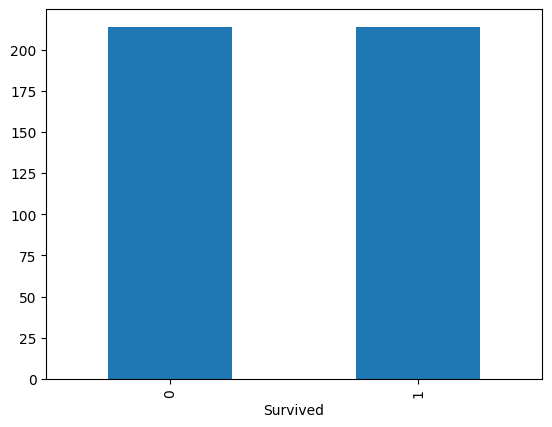

In [30]:
survived_plt = train_under["Survived"].value_counts()
survived_plt.plot(kind="bar")
plt.show()

Now, we have the same amount of observations for both survived and not_survived. Let's see how it can impact our model

- Separating our features from our target

In [31]:
X_train_under = train_under.drop(columns = ["Survived"])
y_train_under = train_under["Survived"]

- Model training

In [32]:
log_reg = LogisticRegression()
log_reg.fit(X_train_under, y_train_under)

LogisticRegression()

- Evaluate our model

In [33]:
y_pred_test_log = log_reg.predict(X_test_scaled_df)
print(classification_report(y_pred = y_pred_test_log, y_true = y_test))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82       104
           1       0.74      0.74      0.74        74

    accuracy                           0.79       178
   macro avg       0.78      0.78      0.78       178
weighted avg       0.79      0.79      0.79       178



#### SMOTE

SMOTE utilizes KNN approach to generate synthetic samples for the minority class.

SMOTE comes from a different package - **imblearn**

In [34]:
from imblearn.over_sampling import SMOTE

Now, we need to create a SMOTE object in order to balance our data

- **sampling_strategy** - corresponds to the ratio of the number of samples in the minority class over the number of samples in the majority class.

In [35]:
sm = SMOTE(random_state = 1,sampling_strategy=1.0)

In [36]:
X_train_sm, y_train_sm =  sm.fit_resample(X_train_scaled_df,y_train) # .fit() doesn't exists!!!

- Now lets train our model, to see if get any improvements.

In [37]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_sm, y_train_sm)

LogisticRegression(max_iter=1000)

- Evaluate our model

In [38]:
y_pred_test_log = log_reg.predict(X_test_scaled_df)
print(classification_report(y_pred = y_pred_test_log, y_true = y_test))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83       104
           1       0.76      0.76      0.76        74

    accuracy                           0.80       178
   macro avg       0.79      0.79      0.79       178
weighted avg       0.80      0.80      0.80       178



In [39]:
from imblearn.over_sampling import RandomOverSampler

over = RandomOverSampler(random_state=0)
X_train_over, y_train_over = over.fit_resample(X_train_scaled_df,y_train)

In [40]:
from imblearn.under_sampling import RandomUnderSampler

under = RandomUnderSampler(random_state=0)
X_train_under, y_train_under = over.fit_resample(X_train_scaled_df,y_train)